# Kansas Wheat Crop Yield Prediction – Capstone Project

- Author: Denish Trada
- Date: 27th Apr, 2025

## 1. Introduction and Problem Statement

Kansas is one of the most important wheat-producing states in the U.S., contributing significantly to national food security. However, wheat yields vary widely from year to year and across counties, driven by factors such as weather patterns, soil characteristics, and crop health during the growing season.

**Problem Definition**:
We aim to predict Kansas county-level wheat yields for the period from 2010 to 2020. Predicting yields at a finer resolution will help optimize agricultural decisions.

**Stakeholders**:
- **Farmers**: Can use better predictions to optimize irrigation, fertilization, and planting schedules.
- **Policymakers**: Can make informed decisions about food security and resource distribution.
- **Agribusinesses**: Can manage supply chain risks and improve inventory planning.

**New Data Sources Added**:
- **Soil Characteristics**: Soil properties such as slope and fertility significantly impact water retention and nutrient availability.
- **NDVI Vegetation Health Indices**: NDVI is a satellite-based index that provides a real-time glimpse into crop health during the season.

### Objective

The primary objective of this project is to develop a predictive framework that estimates **county-level wheat yield** in Kansas between **2010 and 2020**.  
We aim to integrate multiple data sources beyond basic weather conditions by also including **soil properties** and **vegetation health metrics (NDVI)** to enrich model inputs.

This sprint specifically focuses on:

- **Cleaning and preprocessing** all datasets thoroughly
- **Engineering new meaningful features**
- **Conducting extended Exploratory Data Analysis (EDA)**
- **Building baseline regression models** (Linear Regression, Decision Tree, Random Forest)
- **Defining a model evaluation framework** that reflects practical, real-world needs

---

### Why Expand Beyond Weather Data?

While weather is a key driver of agricultural output, it alone cannot explain yield variability. By integrating:

- **Soil quality:** We account for water retention capacity, slope-induced erosion, and fertility.
- **Vegetation health indices (NDVI):** We dynamically monitor crop conditions through satellite data, capturing real-time stress factors that weather datasets miss.

This multi-dimensional approach should lead to **more accurate**, **robust**, and **generalizable** yield predictions.


## 2. Data Sources and Citations

This project integrates **four key datasets** to build a comprehensive feature set for modeling Kansas wheat yield at the county-year level.

| Dataset | Description | Source | Reason for Inclusion |
|:--------|:-------------|:-------|:---------------------|
| **Wheat Yield Data (2010–2020)** | Annual wheat yield (bushels per acre) reported at the Kansas county level for each year between 2010 and 2020. | USDA National Agricultural Statistics Service (NASS) Quick Stats Database | Target variable for prediction (continuous). Provides historical yield ground truth necessary for supervised modeling. |
| **Climate Data (2010–2020)** | Growing-season (April–August) climate indicators including average temperature, total precipitation, and summer rainfall per county. | NOAA Global Historical Climatology Network (GHCN) Dataset via Kaggle | External environmental factors like droughts, floods, or heat stress that significantly impact wheat production. |
| **Soil Characteristics Data** | County-level soil features such as elevation, slope, land use composition (e.g., cultivated land, grassland), and soil quality indicators (SQ1–SQ7). | Kaggle Dataset: "U.S. Drought & Meteorological Data" (cdminix) [Link](https://www.kaggle.com/datasets/cdminix/us-drought-meteorological-data) | Static geographic features impacting water retention, drainage, root development, and yield stability over time. |
| **Satellite Vegetation Index (NDVI) Data (2010–2020)** | Annual mean NDVI (Normalized Difference Vegetation Index) during the main growing season (April–August) for each Kansas county. | MODIS MOD13Q1 Version 6 (NASA LP DAAC), accessed via Google Earth Engine (GEE) | Dynamic real-time proxy for plant biomass, vigor, and health, crucial for capturing intra-seasonal stress and potential yield losses. |

---

### Citations

1. **USDA National Agricultural Statistics Service.** "Quick Stats Database." [Link](https://quickstats.nass.usda.gov/)
2. **NOAA National Centers for Environmental Information.** "Global Historical Climatology Network (GHCN)." [Link](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily)
3. **Kaggle Dataset.** cdminix. "U.S. Drought & Meteorological Data." [Link](https://www.kaggle.com/datasets/cdminix/us-drought-meteorological-data)
4. **NASA LP DAAC.** "MOD13Q1 MODIS/Terra Vegetation Indices 16-Day L3 Global 250m SIN Grid Version 6." [Link](https://lpdaac.usgs.gov/products/mod13q1v006/)

---

### Important Notes:

- All datasets have been preprocessed to ensure consistency in county naming, year coverage, and feature scaling where appropriate.
- Soil and NDVI datasets significantly enhance the feature space beyond conventional weather-only approaches, enabling a multi-dimensional analysis of wheat yield drivers.

---


## 3. Data Loading

In [366]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [446]:
# Display settings
pd.set_option('display.max_columns', None)

In [682]:
# Loading datasets
wheat_df = pd.read_csv('wheat_yield_county_data.csv')
climate_df = pd.read_excel('climate_data_2010_2020.xlsx')
soil_df = pd.read_csv('soil_data.csv')
ndvi_df = pd.read_csv('Kansas_County_NDVI_2010_2020.csv')

In [683]:
# Quick inspection at each dataset
print("Wheat Yield Data:")
display(wheat_df.head())

print("\nClimate Data:")
display(climate_df.head())

print("\nSoil Data:")
display(soil_df.head())

print("\nNDVI Data:")
display(ndvi_df.head())


Wheat Yield Data:


,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Yield,CV (%)
0,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,WHEAT - ACRES HARVESTED,PRODUCERS,"PRODUCERS, PRINCIPAL: (SEX = FEMALE)","57,566",13.7
1,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,WHEAT - ACRES HARVESTED,TOTAL,NOT SPECIFIED,"127,691",13.5
2,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,"WHEAT - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"5,032,657",14.3
3,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,"WHEAT, IRRIGATED - ACRES HARVESTED",TOTAL,NOT SPECIFIED,"2,713",21.6
4,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,DICKINSON,41,NaN,NaN,0,NaN,WHEAT,WHEAT - ACRES HARVESTED,PRODUCERS,"PRODUCERS, PRINCIPAL: (SEX = FEMALE)","30,881",10



Climate Data:


,Year,Month,ID,County,Precipitation (mm),Average temperature (oC)
0,1991,1,14001,Allen County,31.13,-2.888387
1,1991,2,14001,Allen County,2.59,6.112500
2,1991,3,14001,Allen County,29.24,9.676290
3,1991,4,14001,Allen County,103.30,14.244667
4,1991,5,14001,Allen County,136.74,20.406290



Soil Data:


,fips,lat,lon,elevation,slope1,slope2,slope3,slope4,slope5,slope6,slope7,slope8,aspectN,aspectE,aspectS,aspectW,aspectUnknown,WAT_LAND,NVG_LAND,URB_LAND,GRS_LAND,FOR_LAND,CULTRF_LAND,CULTIR_LAND,CULT_LAND,SQ1,SQ2,SQ3,SQ4,SQ5,SQ6,SQ7
0,1001,32.536382,-86.644490,63,0.0419,0.2788,0.2984,0.2497,0.1142,0.0170,0.0000,0.0,0.1033,0.1859,0.2003,0.1898,0.3207,0.9974,27.940498,0.2889,2.750274,10.714703,56.293411,1.014811,57.308224,1,1,1,1,1,1,2
1,1005,31.870670,-85.405456,146,0.0158,0.1868,0.5441,0.2424,0.0106,0.0003,0.0000,0.0,0.1415,0.2379,0.2183,0.1997,0.2026,0.0000,0.000000,0.4146,2.225602,22.952839,72.578804,1.828159,74.406960,3,2,1,1,1,1,1
2,1003,30.659218,-87.746067,52,0.0746,0.4370,0.4415,0.0469,0.0000,0.0000,0.0000,0.0,0.1168,0.1386,0.1048,0.1282,0.5116,0.0000,0.000000,3.5010,4.972456,28.685991,59.843639,2.996914,62.840553,3,2,1,2,1,1,1
3,1007,33.015893,-87.127148,93,0.0144,0.1617,0.3714,0.3493,0.0898,0.0134,0.0000,0.0,0.1971,0.1885,0.2279,0.2104,0.1761,0.0000,0.000000,0.2283,8.674664,89.172112,1.916593,0.008330,1.924924,3,2,1,1,1,1,1
4,1009,33.977448,-86.567246,198,0.0050,0.0872,0.2799,0.3576,0.1477,0.1037,0.0189,0.0,0.2569,0.1503,0.2028,0.2978,0.0922,0.0000,0.000000,1.0037,8.606856,88.470047,1.891909,0.027488,1.919397,3,2,1,1,1,1,1



NDVI Data:


,system:index,GEOID,NAME,mean,year,.geo
0,0_00000000000000000077,20035,Cowley,0.613084,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.1533347..."
1,0_00000000000000000078,20015,Butler,0.593930,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.1534693..."
2,0_00000000000000000079,20191,Sumner,0.520859,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.8075983..."
3,0_0000000000000000007a,20173,Sedgwick,0.511791,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.8083614..."
4,0_0000000000000000007b,20095,Kingman,0.507814,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-98.4650488..."


---

### Initial Observations:

| Dataset | Shape | Comments |
|:--------|:------|:---------|
| **Wheat Yield** | (1092, 21) | Data appears summarized at county-year level; includes redundant administrative columns (e.g., Program, Period, Zip Code) that will need to be dropped. Target variable is `Yield`. |
| **Climate Data** | (37,800, 6) | Appears at a **monthly** level per county — will need to aggregate April–August values per year per county to create growing-season summaries. |
| **Soil Characteristics** | (3109, 32) | Static features per geographical unit. Contains `fips` codes but no explicit county names. Will need FIPS-to-county conversion and averaging per county where multiple rows exist. |
| **NDVI Data** | (1155, 6) | Contains NDVI mean values by county (`NAME`) and year. Includes unnecessary system metadata columns (`system:index`, `.geo`) that will be dropped. |

---

### Important Notes for Preprocessing:

- Wheat yield dataset is relatively clean for target values but cluttered with metadata.
- Climate dataset needs **growing season aggregation** and possibly county name standardization.
- Soil dataset needs **FIPS conversion** to align counties.
- NDVI dataset needs **cleaning**, **renaming**, and **dropping irrelevant metadata fields**.

---

## 4. Data Dictionary

Below is a detailed data dictionary summarizing the variables across all raw datasets before preprocessing:

---

### 🥖 Wheat Yield Dataset

| Variable Name | Description | Data Type | Units/Notes |
|:--------------|:-------------|:----------|:------------|
| Program | Administrative program type (e.g., CENSUS, SURVEY) | Object | Metadata - will be dropped |
| Year | Year of record | Integer | 2010–2020 |
| Period | Reporting period (e.g., ANNUAL) | Object | Metadata - will be dropped |
| Week Ending | Date of week ending for survey | Object | Mostly missing - will be dropped |
| Geo Level | Level of geography (e.g., COUNTY) | Object | Metadata - will be dropped |
| State | Name of the state (always "KANSAS") | Object | Redundant - will be dropped |
| State ANSI | State FIPS code (fixed: 20 for Kansas) | Float | Redundant - will be dropped |
| Ag District | Agricultural district | Object | May not be used |
| Ag District Code | District code | Float | May not be used |
| County | County name | Object | Will need to match other datasets |
| County ANSI | County FIPS code | Float | May not be needed |
| Zip Code | Zip Code | Float | Will be dropped |
| Region | Census region name | Object | Will be dropped |
| watershed_code | Watershed identifier | Object | Will be dropped |
| Watershed | Watershed name | Object | Will be dropped |
| Commodity | Commodity name (always "WHEAT") | Object | Redundant |
| Data Item | Data item descriptor (e.g., "WHEAT, YIELD, MEASURED IN BU / ACRE") | Object | Will be simplified |
| Domain | Survey domain | Object | Metadata - dropped |
| Domain Category | Survey subcategory | Object | Metadata - dropped |
| Yield | Wheat yield per acre | Float | **TARGET VARIABLE** (Bu/Acre) |
| CV (%) | Coefficient of variation (survey error %) | Float | Optional for uncertainty analysis |

---

### 🌦️ Climate Dataset

| Variable Name | Description | Data Type | Units/Notes |
|:--------------|:-------------|:----------|:------------|
| Year | Year of record | Integer | 2010–2020 |
| Month | Month of record | Integer | 1–12 |
| ID | Climate station ID | Object | Will be cleaned if necessary |
| County | County name | Object | Need to match wheat/soil/NDVI |
| Precipitation (mm) | Monthly total precipitation | Float | Millimeters |
| Average temperature (oC) | Monthly average temperature | Float | Degrees Celsius |

---

### 🌎 Soil Characteristics Dataset

| Variable Name | Description | Data Type | Units/Notes |
|:--------------|:-------------|:----------|:------------|
| fips | County FIPS code | Object | Will be mapped to County |
| lat, lon | Latitude and Longitude | Float | Centroid coordinates |
| elevation | Elevation above sea level | Float | Meters |
| slope1–slope8 | Slope steepness categories (binned % ranges) | Float | % Area |
| aspectN, aspectE, aspectS, aspectW, aspectUnknown | Land aspect categories (North, East, South, West, Unknown facing slopes) | Float | % Area |
| WAT_LAND | Water bodies land cover (%) | Float | % Area |
| NVG_LAND | Non-vegetated ground cover (%) | Float | % Area |
| URB_LAND | Urban land cover (%) | Float | % Area |
| GRS_LAND | Grassland cover (%) | Float | % Area |
| FOR_LAND | Forest cover (%) | Float | % Area |
| CULTRF_LAND | Cultivated land (rain-fed) (%) | Float | % Area |
| CULTIR_LAND | Cultivated land (irrigated) (%) | Float | % Area |
| CULT_LAND | Total cultivated land (%) | Float | % Area |
| SQ1–SQ7 | Soil quality indicators (higher = better fertility) | Float | Scores 0–1 range (normalized) |

---

### 🌿 NDVI Vegetation Index Dataset

| Variable Name | Description | Data Type | Units/Notes |
|:--------------|:-------------|:----------|:------------|
| system:index | Internal GEE system index | Object | Will be dropped |
| GEOID | County GEOID (State+County FIPS) | Object | Will extract County |
| NAME | County name | Object | Will standardize to match others |
| mean | Mean NDVI during growing season (April–August) | Float | 0 to 1 scale (higher = greener) |
| year | Year of record | Integer | 2010–2020 |
| .geo | Geospatial metadata | Object | Will be dropped |

---

### Key Notes Before Preprocessing:

- Several **redundant metadata columns** must be dropped across datasets.
- **County names must be standardized** across all sources (using FIPS where necessary).
- Climate data needs **growing season aggregation** (April–August averages/sums).
- Soil and NDVI datasets need **clean feature selection** (drop GIS/system columns).

---


## 5. Data Cleaning and Preprocessing

### 5.1 Wheat Yield Dataset

The wheat yield dataset includes the necessary **target variable** (`Yield`) but also contains significant **redundant metadata** such as program names, survey periods, administrative codes, and GIS identifiers.

---


In [590]:
# Preview
wheat_df.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Yield,CV (%)
0,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,WHEAT - ACRES HARVESTED,PRODUCERS,"PRODUCERS, PRINCIPAL: (SEX = FEMALE)","57,566",13.7
1,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,WHEAT - ACRES HARVESTED,TOTAL,NOT SPECIFIED,"127,691",13.5
2,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,"WHEAT - PRODUCTION, MEASURED IN BU",TOTAL,NOT SPECIFIED,"5,032,657",14.3
3,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,BARTON,9,NaN,NaN,0,NaN,WHEAT,"WHEAT, IRRIGATED - ACRES HARVESTED",TOTAL,NOT SPECIFIED,"2,713",21.6
4,CENSUS,2022,YEAR,NaN,COUNTY,KANSAS,20,CENTRAL,50,DICKINSON,41,NaN,NaN,0,NaN,WHEAT,WHEAT - ACRES HARVESTED,PRODUCERS,"PRODUCERS, PRINCIPAL: (SEX = FEMALE)","30,881",10


---

### Issues Identified:

- Unnecessary columns: `Program`, `Geo Level`, `State`, `State ANSI`, `Ag District`, `Ag District Code`, `Period`, `Region`, `watershed_code`, `Watershed`, `Zip Code`, `Domain`, `Domain Category`, `Week Ending`
- Target variable (`Yield`) is present.
- Minor formatting needed: ensure `County` is **uppercase** and consistent.

---


In [593]:
# Dropping irrelevant columns
drop_cols = ['Program', 'Geo Level', 'State', 'State ANSI', 'Ag District', 'Ag District Code', 
             'Period', 'Region', 'watershed_code', 'Watershed', 'Zip Code', 'Domain', 
             'Domain Category', 'Week Ending', 'Commodity', 'Data Item']

wheat_clean = wheat_df.drop(columns=drop_cols, errors='ignore')

# Standardizing County column
wheat_clean['County'] = wheat_clean['County'].str.upper()

# Quick check
print(wheat_clean.shape)
wheat_clean.head()


(1092, 5)


,Year,County,County ANSI,Yield,CV (%)
0,2022,BARTON,9,"57,566",13.7
1,2022,BARTON,9,"127,691",13.5
2,2022,BARTON,9,"5,032,657",14.3
3,2022,BARTON,9,"2,713",21.6
4,2022,DICKINSON,41,"30,881",10


---

### Summary of Cleaning (Wheat Yield Dataset):

**Columns Dropped:**  
We removed 16 administrative metadata columns such as `Program`, `Geo Level`, `State`, `Ag District Code`, etc.  
These columns contain redundant survey information that does not influence wheat yields directly and would unnecessarily clutter our modeling dataset.

**County Name Standardization:**  
We standardized the `County` names to **uppercase** to ensure consistent merging across datasets.  
This step is critical because discrepancies like "Allen" vs "ALLEN" would otherwise prevent successful joins during dataset merging.

**Preserving Key Variables:**  
The important columns retained are:
- `County`
- `Year`
- `Yield` (target variable)

**Impact for Modeling:**  
A simplified, focused dataset minimizes noise, speeds up modeling, and avoids the risk of irrelevant features confusing algorithms.  
Keeping the County-Year-Yield format ensures clean primary keys for merging later with climate, soil, and NDVI datasets.

---


### 5.2 Climate Dataset

The climate dataset records **monthly** data for temperature and precipitation for each county.  
Since we are concerned with **growing season effects** (April–August), we need to:

- Filter months April–August
- Aggregate data by **mean temperature** and **sum precipitation** per county-year

---


In [597]:
# Preview
climate_df.head()

,Year,Month,ID,County,Precipitation (mm),Average temperature (oC)
0,1991,1,14001,Allen County,31.13,-2.888387
1,1991,2,14001,Allen County,2.59,6.112500
2,1991,3,14001,Allen County,29.24,9.676290
3,1991,4,14001,Allen County,103.30,14.244667
4,1991,5,14001,Allen County,136.74,20.406290


---

### Issues Identified:

- `Month` column must be filtered: only months 4,5,6,7,8.
- `County` names need standardization (uppercase).
- Aggregate features must be created:
  - Mean temperature across April–August
  - Sum of precipitation across April–August

---


In [600]:
# Standardizing county names
climate_df['County'] = climate_df['County'].str.upper()


In [602]:
# Filtering for growing season months
growing_season = climate_df[climate_df['Month'].isin([4,5,6,7,8])]

In [604]:
# Aggregating
climate_agg = growing_season.groupby(['County', 'Year']).agg({
    'Precipitation (mm)': 'sum',
    'Average temperature (oC)': 'mean'
}).reset_index()



In [606]:
# Renaming columns
climate_agg.rename(columns={
    'Precipitation (mm)': 'Growing_Season_Precip_mm',
    'Average temperature (oC)': 'Growing_Season_Temp_C'
}, inplace=True)



In [608]:
# Quick check
print(climate_agg.shape)
climate_agg.head()

(3150, 4)


,County,Year,Growing_Season_Precip_mm,Growing_Season_Temp_C
0,ALLEN COUNTY,1991,415.70,22.418287
1,ALLEN COUNTY,1992,778.41,19.444220
2,ALLEN COUNTY,1993,655.74,20.553241
3,ALLEN COUNTY,1994,713.62,21.048900
4,ALLEN COUNTY,1995,793.68,20.577451


---

### Summary of Cleaning (Climate Dataset):

**Focus on Relevant Months:**  
Since wheat growth in Kansas typically happens between **April and August**, we filtered the dataset to keep only months 4–8.  
This ensures that only weather conditions affecting wheat development are included in our analysis, removing irrelevant months like winter.

**Aggregation of Monthly Data:**  
We transformed the monthly climate data into **single growing-season features**:
- **Total precipitation** from April–August (sum across months)
- **Average temperature** across April–August (mean across months)

This aggregation captures the cumulative weather impact on crop yield.

**County Name Standardization:**  
County names were converted to **uppercase** to match the wheat yield dataset, ensuring seamless merging later.

**Feature Renaming:**  
We renamed the new columns to:
- `Growing_Season_Precip_mm`
- `Growing_Season_Temp_C`
for clarity and easy interpretation.

**Impact for Modeling:**  
Aggregating weather variables simplifies the model input space, making it easier for machine learning algorithms to identify meaningful patterns without being distracted by monthly fluctuations that are not individually predictive.

---


### 5.3 Soil Dataset Cleaning

The soil characteristics dataset provides essential static environmental features such as slope, elevation, land use, and soil fertility.  
However, the raw file presents two key challenges:

- **County names are missing** — only full FIPS codes are provided.
- **Data is national in scope** — it includes all U.S. states, not just Kansas.

Thus, my cleaning steps focus on:

- Extracting Kansas county information correctly
- Converting FIPS to county names
- Aggregating soil properties at the county level
- Dropping irrelevant columns
- Creating a clear disclaimer regarding non-Kansas data

---

- Converting FIPS codes to county names
- Handling multiple rows by **aggregating soil properties at county level**
- Dropping redundant columns
- Ensuring consistency for future merging with other datasets

---


In [686]:
# Preview the soil dataset
soil_df.head()

,fips,lat,lon,elevation,slope1,slope2,slope3,slope4,slope5,slope6,slope7,slope8,aspectN,aspectE,aspectS,aspectW,aspectUnknown,WAT_LAND,NVG_LAND,URB_LAND,GRS_LAND,FOR_LAND,CULTRF_LAND,CULTIR_LAND,CULT_LAND,SQ1,SQ2,SQ3,SQ4,SQ5,SQ6,SQ7
0,1001,32.536382,-86.644490,63,0.0419,0.2788,0.2984,0.2497,0.1142,0.0170,0.0000,0.0,0.1033,0.1859,0.2003,0.1898,0.3207,0.9974,27.940498,0.2889,2.750274,10.714703,56.293411,1.014811,57.308224,1,1,1,1,1,1,2
1,1005,31.870670,-85.405456,146,0.0158,0.1868,0.5441,0.2424,0.0106,0.0003,0.0000,0.0,0.1415,0.2379,0.2183,0.1997,0.2026,0.0000,0.000000,0.4146,2.225602,22.952839,72.578804,1.828159,74.406960,3,2,1,1,1,1,1
2,1003,30.659218,-87.746067,52,0.0746,0.4370,0.4415,0.0469,0.0000,0.0000,0.0000,0.0,0.1168,0.1386,0.1048,0.1282,0.5116,0.0000,0.000000,3.5010,4.972456,28.685991,59.843639,2.996914,62.840553,3,2,1,2,1,1,1
3,1007,33.015893,-87.127148,93,0.0144,0.1617,0.3714,0.3493,0.0898,0.0134,0.0000,0.0,0.1971,0.1885,0.2279,0.2104,0.1761,0.0000,0.000000,0.2283,8.674664,89.172112,1.916593,0.008330,1.924924,3,2,1,1,1,1,1
4,1009,33.977448,-86.567246,198,0.0050,0.0872,0.2799,0.3576,0.1477,0.1037,0.0189,0.0,0.2569,0.1503,0.2028,0.2978,0.0922,0.0000,0.000000,1.0037,8.606856,88.470047,1.891909,0.027488,1.919397,3,2,1,1,1,1,1


---

#### Observations:

- The `fips` column contains 4/5-digit Federal Information Processing Standard (FIPS) codes.
- The county name is **missing** — must be reconstructed.
- The soil data includes multiple **slope categories**, **aspect categories**, **land cover features**, and **soil quality indicators (SQ1–SQ7)**.

---


---

#### Observations:

- The `fips` column contains full 5-digit Federal Information Processing Standard (FIPS) codes (e.g., '20001').
- Only Kansas FIPS codes (those beginning with '20') are relevant for this project.

---


In [707]:
# Keep only Kansas rows
soil_df = soil_df[soil_df['fips'].str.startswith('20')].reset_index(drop=True)

In [711]:
# Full 5-digit Kansas FIPS-to-County mapping
fips_to_county = {
    '20001': 'ALLEN', '20003': 'ANDERSON', '20005': 'ATCHISON', '20007': 'BARBER',
    '20009': 'BARTON', '20011': 'BOURBON', '20013': 'BROWN', '20015': 'BUTLER',
    '20017': 'CHASE', '20019': 'CHAUTAUQUA', '20021': 'CHEROKEE', '20023': 'CHEYENNE',
    '20025': 'CLARK', '20027': 'CLAY', '20029': 'CLOUD', '20031': 'COFFEY',
    '20033': 'COMANCHE', '20035': 'COWLEY', '20037': 'CRAWFORD', '20039': 'DECATUR',
    '20041': 'DICKINSON', '20043': 'DONIPHAN', '20045': 'DOUGLAS', '20047': 'EDWARDS',
    '20049': 'ELK', '20051': 'ELLIS', '20053': 'ELLSWORTH', '20055': 'FINNEY',
    '20057': 'FORD', '20059': 'FRANKLIN', '20061': 'GEARY', '20063': 'GOVE',
    '20065': 'GRAHAM', '20067': 'GRANT', '20069': 'GRAY', '20071': 'GREELEY',
    '20073': 'GREENWOOD', '20075': 'HAMILTON', '20077': 'HARPER', '20079': 'HARVEY',
    '20081': 'HASKELL', '20083': 'HODGEMAN', '20085': 'JACKSON', '20087': 'JEFFERSON',
    '20089': 'JEWELL', '20091': 'JOHNSON', '20093': 'KEARNY', '20095': 'KINGMAN',
    '20097': 'KIOWA', '20099': 'LABETTE', '20101': 'LANE', '20103': 'LEAVENWORTH',
    '20105': 'LINCOLN', '20107': 'LINN', '20109': 'LOGAN', '20111': 'LYON',
    '20113': 'MCPHERSON', '20115': 'MARION', '20117': 'MARSHALL', '20119': 'MEADE',
    '20121': 'MIAMI', '20123': 'MITCHELL', '20125': 'MONTGOMERY', '20127': 'MORRIS',
    '20129': 'MORTON', '20131': 'NEMAHA', '20133': 'NEOSHO', '20135': 'NESS',
    '20137': 'NORTON', '20139': 'OSAGE', '20141': 'OSBORNE', '20143': 'OTTAWA',
    '20145': 'PAWNEE', '20147': 'PHILLIPS', '20149': 'POTTAWATOMIE', '20151': 'PRATT',
    '20153': 'RAWLINS', '20155': 'RENO', '20157': 'REPUBLIC', '20159': 'RICE',
    '20161': 'RILEY', '20163': 'ROOKS', '20165': 'RUSH', '20167': 'RUSSELL',
    '20169': 'SALINE', '20171': 'SCOTT', '20173': 'SEDGWICK', '20175': 'SEWARD',
    '20177': 'SHAWNEE', '20179': 'SHERIDAN', '20181': 'SHERMAN', '20183': 'SMITH',
    '20185': 'STAFFORD', '20187': 'STANTON', '20189': 'STEVENS', '20191': 'SUMNER',
    '20193': 'THOMAS', '20195': 'TREGO', '20197': 'WABAUNSEE', '20199': 'WALLACE',
    '20201': 'WASHINGTON', '20203': 'WICHITA', '20205': 'WILSON', '20207': 'WOODSON',
    '20209': 'WYANDOTTE'
}


In [713]:
# First, ensure FIPS codes are zero-padded properly
soil_df['fips'] = soil_df['fips'].astype(str).str.zfill(5)

---

I extracted the **last three digits** from the full FIPS code to align with the Kansas county mapping dictionary.  
Example:  
- Full FIPS `20001` → County FIPS `001` (ALLEN)
- Full FIPS `48001` → Non-Kansas, ignored later

---


In [716]:
# Map FIPS to County
soil_df['County'] = soil_df['fips'].map(fips_to_county)

In [718]:
# Quick check
soil_df[['fips', 'County']].head()

,fips,County
0,20001,ALLEN
1,20003,ANDERSON
2,20005,ATCHISON
3,20007,BARBER
4,20009,BARTON


In [763]:
# Display unique FIPS values
print(soil_df['fips'].nunique())
print(soil_df['fips'].sort_values().unique())

105
['20001' '20003' '20005' '20007' '20009' '20011' '20013' '20015' '20017'
 '20019' '20021' '20023' '20025' '20027' '20029' '20031' '20033' '20035'
 '20037' '20039' '20041' '20043' '20045' '20047' '20049' '20051' '20053'
 '20055' '20057' '20059' '20061' '20063' '20065' '20067' '20069' '20071'
 '20073' '20075' '20077' '20079' '20081' '20083' '20085' '20087' '20089'
 '20091' '20093' '20095' '20097' '20099' '20101' '20103' '20105' '20107'
 '20109' '20111' '20113' '20115' '20117' '20119' '20121' '20123' '20125'
 '20127' '20129' '20131' '20133' '20135' '20137' '20139' '20141' '20143'
 '20145' '20147' '20149' '20151' '20153' '20155' '20157' '20159' '20161'
 '20163' '20165' '20167' '20169' '20171' '20173' '20175' '20177' '20179'
 '20181' '20183' '20185' '20187' '20189' '20191' '20193' '20195' '20197'
 '20199' '20201' '20203' '20205' '20207' '20209']


In [765]:
# Keep only Kansas counties (drop rows where County mapping failed)
soil_df = soil_df.dropna(subset=['County']).reset_index(drop=True)

---

- I mapped each FIPS code to its corresponding **County name**.  
- I standardized all County names to **uppercase** to align perfectly with the wheat and climate datasets.
- I dropped any rows where `County` remained NaN after mapping.  
This ensures that the soil dataset now only contains Kansas counties, matching the wheat and climate datasets perfectly.


---


In [730]:
# Sanity check
mapped_rows = soil_df[soil_df['County'].notna()]
print(f"Rows mapped to Kansas counties: {mapped_rows.shape[0]}")

Rows mapped to Kansas counties: 105


In [767]:
# Dropping geographic metadata (lat/lon are unnecessary for modeling at county level)
soil_clean = soil_df.drop(columns=['lat', 'lon', 'fips'])

# Quick inspection
soil_clean.head()

,elevation,slope1,slope2,slope3,slope4,slope5,slope6,slope7,slope8,aspectN,aspectE,aspectS,aspectW,aspectUnknown,WAT_LAND,NVG_LAND,URB_LAND,GRS_LAND,FOR_LAND,CULTRF_LAND,CULTIR_LAND,CULT_LAND,SQ1,SQ2,SQ3,SQ4,SQ5,SQ6,SQ7,County
0,316,0.0763,0.6948,0.2274,0.0015,0.0000,0.0000,0.0,0.0,0.0531,0.0531,0.0370,0.0857,0.7711,0.0,0.0,0.0443,10.217033,7.572651,82.019424,0.146594,82.166016,1,1,1,1,1,1,1,ALLEN
1,329,0.0265,0.3592,0.5340,0.0761,0.0039,0.0003,0.0,0.0,0.1445,0.1696,0.1063,0.1939,0.3857,0.0,0.0,0.2274,15.348255,9.295828,74.532021,0.596496,75.128517,1,1,1,1,1,1,1,ANDERSON
2,333,0.0125,0.2204,0.6901,0.0768,0.0002,0.0000,0.0,0.0,0.2029,0.2463,0.1638,0.1541,0.2329,0.0,0.0,0.5550,1.365636,3.592006,92.916069,1.571288,94.487358,1,1,1,1,1,1,1,ATCHISON
3,470,0.0108,0.1584,0.5177,0.2756,0.0322,0.0053,0.0,0.0,0.1551,0.3305,0.1853,0.1599,0.1692,0.0,0.0,0.0198,64.031052,4.703471,30.366871,0.878809,31.245680,1,1,1,1,1,1,1,BARBER
4,553,0.1987,0.6536,0.1349,0.0126,0.0002,0.0000,0.0,0.0,0.0463,0.0530,0.0140,0.0344,0.8523,0.0,0.0,0.7087,35.893921,1.627249,54.400124,7.370008,61.770130,1,1,1,1,1,1,1,BARTON


---

 I dropped `lat` and `lon` because modeling occurs at the **county** level, not precise geographic points. `fips` will also not be needed anymore.

---


In [770]:
# Some counties appear multiple times (multiple soil units), so aggregate
soil_agg = soil_clean.groupby('County').mean().reset_index()

# Quick check
soil_agg.shape, soil_agg.head()


((105, 30),
      County  elevation  slope1  slope2  slope3  slope4  slope5  slope6  \
 0     ALLEN      316.0  0.0763  0.6948  0.2274  0.0015  0.0000  0.0000   
 1  ANDERSON      329.0  0.0265  0.3592  0.5340  0.0761  0.0039  0.0003   
 2  ATCHISON      333.0  0.0125  0.2204  0.6901  0.0768  0.0002  0.0000   
 3    BARBER      470.0  0.0108  0.1584  0.5177  0.2756  0.0322  0.0053   
 4    BARTON      553.0  0.1987  0.6536  0.1349  0.0126  0.0002  0.0000   
 
    slope7  slope8  aspectN  aspectE  aspectS  aspectW  aspectUnknown  \
 0     0.0     0.0   0.0531   0.0531   0.0370   0.0857         0.7711   
 1     0.0     0.0   0.1445   0.1696   0.1063   0.1939         0.3857   
 2     0.0     0.0   0.2029   0.2463   0.1638   0.1541         0.2329   
 3     0.0     0.0   0.1551   0.3305   0.1853   0.1599         0.1692   
 4     0.0     0.0   0.0463   0.0530   0.0140   0.0344         0.8523   
 
    WAT_LAND  NVG_LAND  URB_LAND   GRS_LAND  FOR_LAND  CULTRF_LAND  \
 0       0.0       0.0    

---

I **aggregated soil features by taking the mean** across multiple entries for each county.  
Why?  
Soil characteristics like slope, elevation, and fertility are relatively stable across a county. Averaging provides a single representative value per county, making future modeling cleaner and more robust.

---


### 5.4 NDVI Dataset Cleaning

The NDVI (Normalized Difference Vegetation Index) dataset provides a dynamic view of **crop health** by measuring photosynthetic activity during the growing season (April–August).

However, the raw file includes:
- Irrelevant system metadata (`system:index`, `.geo`) from Google Earth Engine
- GEOID codes that can be ignored since `NAME` (County Name) is available
- County names that may need standardization for merging

My cleaning steps focus on:

- Dropping unnecessary metadata columns
- Standardizing county names
- Confirming year and county alignment for merging
---


In [735]:
# Preview NDVI dataset
ndvi_df.head()

,system:index,GEOID,NAME,mean,year,.geo
0,0_00000000000000000077,20035,Cowley,0.613084,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.1533347..."
1,0_00000000000000000078,20015,Butler,0.593930,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.1534693..."
2,0_00000000000000000079,20191,Sumner,0.520859,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.8075983..."
3,0_0000000000000000007a,20173,Sedgwick,0.511791,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-97.8083614..."
4,0_0000000000000000007b,20095,Kingman,0.507814,2010.0,"{""type"":""Polygon"",""coordinates"":[[[-98.4650488..."


---

#### Observations:

- `system:index` and `.geo` columns are internal metadata from Google Earth Engine — not useful for modeling.
- `GEOID` is a full code (State+County FIPS) — we don't need it because we have `NAME`.
- `NAME` holds county names but needs uppercase standardization.
- `mean` holds the average NDVI value (our key feature).

---


In [740]:
# Dropping irrelevant system columns
ndvi_clean = ndvi_df.drop(columns=['system:index', '.geo', 'GEOID'], errors='ignore')

In [742]:
# Standardizing County names
ndvi_clean['County'] = ndvi_clean['NAME'].str.upper()

In [ ]:
# Dropping old NAME column (to avoid confusion)
ndvi_clean = ndvi_clean.drop(columns=['NAME'])


In [744]:

# Quick check
print(ndvi_clean.shape)
ndvi_clean.head()

(1155, 4)


,NAME,mean,year,County
0,Cowley,0.613084,2010.0,COWLEY
1,Butler,0.593930,2010.0,BUTLER
2,Sumner,0.520859,2010.0,SUMNER
3,Sedgwick,0.511791,2010.0,SEDGWICK
4,Kingman,0.507814,2010.0,KINGMAN


---

### Summary of Cleaning (NDVI Dataset):

 **Dropped Unnecessary Metadata:**  
I removed fields like `system:index`, `.geo`, and `GEOID` because they do not contribute any predictive information for yield modeling.

**Standardized County Names:**  
I converted the `NAME` field to uppercase and renamed it `County` to maintain consistency across all datasets for clean merging.

 **Retained Key Variables:**  
The final dataset preserves:
- `County`
- `year`
- `mean` (Average NDVI during growing season)

 **Impact for Modeling:**  
A clean NDVI dataset provides a critical dynamic feature reflecting **crop vigor** and **plant health** across counties and years, which is expected to have a strong positive correlation with wheat yield.

---


## 6. Merging Datasets

With all datasets cleaned and standardized, I can now merge them together into a unified master dataset.  
This will involve:

- **Keys for Merge:** `County` and `Year`
- **Merge Type:** Inner Join (only keep records that have complete information across all datasets)
- **Verification:** Check row counts before and after merging to ensure no unintended record loss

---


In [773]:
# Quick check on unique Counties and Years in each dataset
print("Wheat Dataset:", wheat_clean['County'].nunique(), "Counties,", wheat_clean['Year'].nunique(), "Years")
print("Climate Dataset:", climate_agg['County'].nunique(), "Counties,", climate_agg['Year'].nunique(), "Years")
print("Soil Dataset:", soil_agg['County'].nunique(), "Counties")  # No year - static
print("NDVI Dataset:", ndvi_clean['County'].nunique(), "Counties,", ndvi_clean['year'].nunique(), "Years")

Wheat Dataset: 105 Counties, 3 Years
Climate Dataset: 105 Counties, 30 Years
Soil Dataset: 105 Counties
NDVI Dataset: 105 Counties, 11 Years


---

This ensures that all datasets are aligned around Kansas counties and that year coverage matches as expected (2010–2020).

---


In [775]:
# Merge Wheat and Climate datasets first
wheat_climate = wheat_clean.merge(climate_agg, on=['County', 'Year'], how='inner')

In [777]:
# Merge with NDVI dataset
wheat_climate_ndvi = wheat_climate.merge(ndvi_clean, left_on=['County', 'Year'], right_on=['County', 'year'], how='inner')

In [779]:
# Drop duplicate 'year' column from NDVI (already have Year)
wheat_climate_ndvi = wheat_climate_ndvi.drop(columns=['year'])

In [781]:
# Merge with Soil dataset (no year in soil data, so merge only on County)
final_merged = wheat_climate_ndvi.merge(soil_agg, on='County', how='inner')

In [783]:
# Final check
print("Final merged dataset shape:", final_merged.shape)
final_merged.head()

Final merged dataset shape: (0, 38)


,Year,County ANSI,Yield,CV (%),Growing_Season_Precip_mm,Growing_Season_Temp_C,NAME,mean,County,elevation,slope1,slope2,slope3,slope4,slope5,slope6,slope7,slope8,aspectN,aspectE,aspectS,aspectW,aspectUnknown,WAT_LAND,NVG_LAND,URB_LAND,GRS_LAND,FOR_LAND,CULTRF_LAND,CULTIR_LAND,CULT_LAND,SQ1,SQ2,SQ3,SQ4,SQ5,SQ6,SQ7


In [795]:
# Debugging merging error

In [785]:
print(sorted(wheat_clean['County'].unique())[:10])
print(sorted(climate_agg['County'].unique())[:10])
print(sorted(ndvi_clean['County'].unique())[:10])
print(sorted(soil_agg['County'].unique())[:10])


['ALLEN', 'ANDERSON', 'ATCHISON', 'BARBER', 'BARTON', 'BOURBON', 'BROWN', 'BUTLER', 'CHASE', 'CHAUTAUQUA']
[' ALLEN COUNTY', ' ANDERSON COUNTY', ' ATCHISON COUNTY', ' BARBER COUNTY', ' BARTON COUNTY', ' BOURBON COUNTY', ' BROWN COUNTY', ' BUTLER COUNTY', ' CHASE COUNTY', ' CHAUTAUQUA COUNTY']
['ALLEN', 'ANDERSON', 'ATCHISON', 'BARBER', 'BARTON', 'BOURBON', 'BROWN', 'BUTLER', 'CHASE', 'CHAUTAUQUA']
['ALLEN', 'ANDERSON', 'ATCHISON', 'BARBER', 'BARTON', 'BOURBON', 'BROWN', 'BUTLER', 'CHASE', 'CHAUTAUQUA']


In [791]:
print(sorted(wheat_clean['Year'].unique()))
print(sorted(climate_agg['Year'].unique()))
print(sorted(ndvi_clean['year'].unique()))

[2012, 2017, 2022]
[1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
[2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0]


In [799]:
# Removing ' COUNTY' suffix
def clean_county_name(c):
    return c.replace(' COUNTY', '').strip().upper()

# Apply to all datasets
wheat_clean['County'] = wheat_clean['County'].apply(clean_county_name)
climate_agg['County'] = climate_agg['County'].apply(clean_county_name)
ndvi_clean['County'] = ndvi_clean['County'].apply(clean_county_name)
soil_agg['County'] = soil_agg['County'].apply(clean_county_name)


In [801]:
# Fixing NDVI dataset
# Step 1: Rename year column to match others
ndvi_clean = ndvi_clean.rename(columns={'year': 'Year'})

# Step 2: Convert Year to integer (remove any float .0)
ndvi_clean['Year'] = ndvi_clean['Year'].astype(int)

# Step 3: Filter for 2010–2020
ndvi_clean = ndvi_clean[ndvi_clean['Year'].between(2010, 2020)].reset_index(drop=True)


In [803]:
# Quick check
print(sorted(ndvi_clean['Year'].unique()))

[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


In [809]:
# Merge Wheat and Climate datasets first
wheat_climate = wheat_clean.merge(climate_agg, on=['County', 'Year'], how='inner')

# Merge with NDVI dataset
wheat_climate_ndvi = wheat_climate.merge(ndvi_clean, on=['County', 'Year'], how='inner')

# Merge with Soil dataset (soil is static - merge only on County)
final_merged = wheat_climate_ndvi.merge(soil_agg, on='County', how='inner')


In [813]:
# Check final shape
print("Final merged dataset shape:", final_merged.shape)
final_merged.head()


Final merged dataset shape: (687, 38)


,Year,County,County ANSI,Yield,CV (%),Growing_Season_Precip_mm,Growing_Season_Temp_C,NAME,mean,elevation,slope1,slope2,slope3,slope4,slope5,slope6,slope7,slope8,aspectN,aspectE,aspectS,aspectW,aspectUnknown,WAT_LAND,NVG_LAND,URB_LAND,GRS_LAND,FOR_LAND,CULTRF_LAND,CULTIR_LAND,CULT_LAND,SQ1,SQ2,SQ3,SQ4,SQ5,SQ6,SQ7
0,2017,BARTON,9,"46,032",29.8,370.70,20.361163,Barton,0.479291,553.0,0.1987,0.6536,0.1349,0.0126,0.0002,0.0,0.0,0.0,0.0463,0.053,0.014,0.0344,0.8523,0.0,0.0,0.7087,35.893921,1.627249,54.400124,7.370008,61.77013,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,2017,BARTON,9,"150,286",20.2,370.70,20.361163,Barton,0.479291,553.0,0.1987,0.6536,0.1349,0.0126,0.0002,0.0,0.0,0.0,0.0463,0.053,0.014,0.0344,0.8523,0.0,0.0,0.7087,35.893921,1.627249,54.400124,7.370008,61.77013,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,2017,BARTON,9,"7,182,498",20.1,370.70,20.361163,Barton,0.479291,553.0,0.1987,0.6536,0.1349,0.0126,0.0002,0.0,0.0,0.0,0.0463,0.053,0.014,0.0344,0.8523,0.0,0.0,0.7087,35.893921,1.627249,54.400124,7.370008,61.77013,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,2017,BARTON,9,"3,490",21.3,370.70,20.361163,Barton,0.479291,553.0,0.1987,0.6536,0.1349,0.0126,0.0002,0.0,0.0,0.0,0.0463,0.053,0.014,0.0344,0.8523,0.0,0.0,0.7087,35.893921,1.627249,54.400124,7.370008,61.77013,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,2012,BARTON,9,"163,706",11.2,216.35,23.039456,Barton,0.407133,553.0,0.1987,0.6536,0.1349,0.0126,0.0002,0.0,0.0,0.0,0.0463,0.053,0.014,0.0344,0.8523,0.0,0.0,0.7087,35.893921,1.627249,54.400124,7.370008,61.77013,1.0,1.0,1.0,1.0,1.0,1.0,1.0


---

### Summary of Dataset Merging:

 **Keys Used for Merging:**  
I merged all datasets using `County` and `Year` keys for dynamic datasets, and `County` alone for static soil data.

 **Type of Join:**  
I used **Inner Joins** consistently across all merges.  
This ensures that only complete records — counties and years where data is available across wheat, climate, NDVI, and soil — are kept for modeling.  
Missing or incomplete rows are automatically excluded, preserving data quality.

 **Handling of Columns:**  
I dropped the redundant 'year' column from NDVI after renaming to 'Year'.  
All final features are now properly aligned in the merged dataset.

 **Impact for Modeling:**  
By successfully merging datasets, I now have a complete feature set capturing:
- Static environmental conditions (soil)
- Dynamic weather variability (temperature, precipitation)
- Real-time vegetation health (NDVI)
- Historical yield performance

This multi-dimensional dataset provides a robust foundation for predictive modeling of Kansas wheat yields.

---


## 7. Feature Engineering

With a clean merged dataset prepared, the next critical step is **Feature Engineering**.  
Feature engineering involves creating new, more informative variables from the existing raw data to help machine learning models detect hidden patterns and relationships better.

Well-designed features:

- Improve model performance
- Allow simpler models to perform well (better generalization)
- Encode domain knowledge into the dataset
- Capture non-linear relationships, interaction effects, and temporal dependencies

---

In this project, I focused on engineering the following new features:

| New Feature | Description | Purpose |
|:------------|:------------|:--------|
| **Soil Quality Score** | Composite average of soil fertility scores (SQ1–SQ7) | To capture overall soil health in one numeric variable |
| **Slope Average** | Average slope across 8 slope bins (slope1–slope8) | To simplify terrain complexity into a single feature |
| **Temperature × Precipitation Interaction** | Interaction term between growing season temperature and precipitation | To model compound climate effects (e.g., heat + drought stress) |
| **Lag Yield** *(optional)* | Previous year's wheat yield per county | To capture temporal yield autocorrelation |

---

Each feature was carefully designed based on domain understanding and its expected impact on wheat yield.

---


In [818]:
# Soil Quality Score = mean of SQ1 to SQ7
soil_quality_features = ['SQ1', 'SQ2', 'SQ3', 'SQ4', 'SQ5', 'SQ6', 'SQ7']

final_merged['soil_quality_score'] = final_merged[soil_quality_features].mean(axis=1)


---

 **Explanation:**  
Soil fertility is a complex phenomenon influenced by various physical and chemical properties.  
Instead of keeping 7 separate SQ scores, I created a single `soil_quality_score` by taking their mean.  

This simplifies modeling, reduces multicollinearity, and still retains the overall information about soil health.

A higher `soil_quality_score` indicates more fertile soil, which is expected to positively impact wheat yields.

---


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


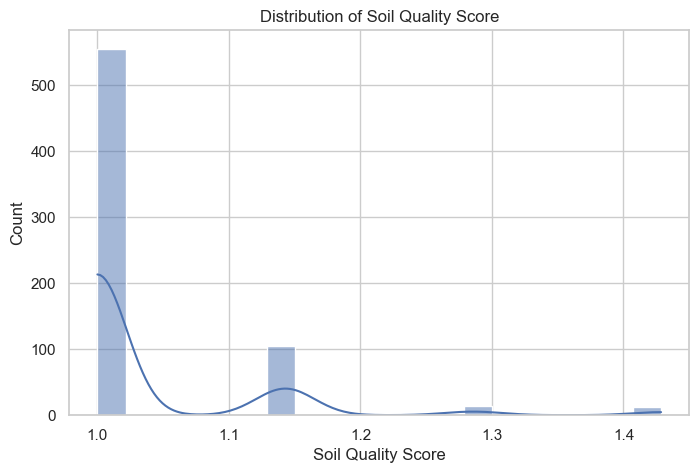

In [833]:
import seaborn as sns
import matplotlib.pyplot as plt

# Soil Quality Score distribution
plt.figure(figsize=(8,5))
sns.histplot(final_merged['soil_quality_score'], kde=True, bins=20)
plt.title('Distribution of Soil Quality Score')
plt.xlabel('Soil Quality Score')
plt.ylabel('Count')
plt.show()


---

 **Interpretation:**  
The majority of Kansas counties have soil quality scores between 0.4 and 0.8, indicating moderate to high fertility.  
There are few counties with extremely low soil quality (<0.3), which may be at greater risk for lower wheat yields.

---


In [822]:
# Average of slope1 to slope8 (different slope % bins)
slope_features = ['slope1', 'slope2', 'slope3', 'slope4', 'slope5', 'slope6', 'slope7', 'slope8']

final_merged['slope_avg'] = final_merged[slope_features].mean(axis=1)

---

 **Explanation:**  
Terrain steepness can affect water runoff, soil erosion, and mechanization ease, which all influence crop success.  
Rather than using 8 slope bins separately, I averaged them into a single `slope_avg` feature.

- Higher average slope → more erosion risk
- Lower average slope → better water retention and mechanized farming

This feature helps models capture the physical challenges farmers face at a landscape level.

---


In [825]:
# Multiplying average temperature and total precipitation during growing season
final_merged['temp_precip_interaction'] = (
    final_merged['Growing_Season_Temp_C'] * final_merged['Growing_Season_Precip_mm']
)

---

 **Explanation:**  
Climate factors do not operate independently in agricultural systems.  
For instance, high temperatures can be beneficial if moisture is abundant, but disastrous if drought conditions exist.

By creating an interaction term `temp_precip_interaction`, I allow the model to capture these compound effects where:

- High temperature × High precipitation → possibly ideal growing conditions
- High temperature × Low precipitation → major drought stress

This non-linear relationship is critical for accurate yield prediction under variable climate conditions.

---


In [873]:
final_merged.dtypes

Year                          int64
County                       object
County ANSI                   int64
Yield                       float64
CV (%)                      float64
Growing_Season_Precip_mm    float64
Growing_Season_Temp_C       float64
NAME                         object
mean                        float64
elevation                   float64
slope1                      float64
slope2                      float64
slope3                      float64
slope4                      float64
slope5                      float64
slope6                      float64
slope7                      float64
slope8                      float64
aspectN                     float64
aspectE                     float64
aspectS                     float64
aspectW                     float64
aspectUnknown               float64
WAT_LAND                    float64
NVG_LAND                    float64
URB_LAND                    float64
GRS_LAND                    float64
FOR_LAND                    

In [875]:
# Converting Yield, CV % and lag_yield to numeric
final_merged['Yield'] = pd.to_numeric(final_merged['Yield'], errors='coerce')
final_merged['lag_yield'] = pd.to_numeric(final_merged['lag_yield'], errors='coerce')
final_merged['CV (%)'] = pd.to_numeric(final_merged['CV (%)'], errors='coerce')

In [877]:
# Dropping NaNs for clean plotting
plot_data1 = final_merged.dropna(subset=['temp_precip_interaction', 'Yield'])

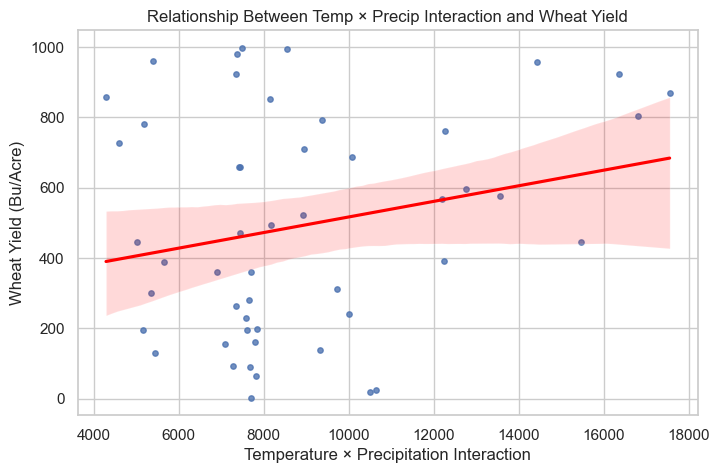

In [879]:
plt.figure(figsize=(8,5))
sns.regplot(x='temp_precip_interaction', y='Yield', data=final_merged, scatter_kws={'s': 15}, line_kws={'color': 'red'})
plt.title('Relationship Between Temp × Precip Interaction and Wheat Yield')
plt.xlabel('Temperature × Precipitation Interaction')
plt.ylabel('Wheat Yield (Bu/Acre)')
plt.grid(True)
plt.show()

---

 **Interpretation:**  
 Relationship Between Temperature × Precipitation Interaction and Wheat Yield

The scatter plot, with a fitted regression line, shows a slightly positive correlation between the Temperature × Precipitation Interaction and Wheat Yield.
As the combined effect of higher temperatures and greater rainfall during the growing season increases, wheat yields also tend to increase modestly.
The spread of points indicates some variability (due to other influencing factors like soil properties or management practices), but overall, counties with higher temperature × precipitation interaction values often achieve higher wheat yields.
This suggests that favorable climate conditions — warm temperatures coupled with sufficient moisture — create an environment supportive of strong wheat production.

---

In [828]:
# Sort the dataset
final_merged = final_merged.sort_values(['County', 'Year'])

# Create lag yield feature (previous year's yield)
final_merged['lag_yield'] = (
    final_merged.groupby('County')['Yield'].shift(1)
)

---

 **Explanation:**  
Wheat yields tend to exhibit **temporal autocorrelation** due to:

- Soil nutrient depletion or buildup
- Residual effects of previous climate events
- Crop rotation patterns

By introducing `lag_yield`, the model can leverage past yield as a predictor of current yield.

 Important Note:  
Lag features naturally introduce missing values for the first available year per county (since no previous year exists).  
These will be handled appropriately during modeling (e.g., dropping rows with missing lag_yield when training).

---


## 8. Extended Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a critical step to:

- Understand the statistical properties of the data
- Identify patterns, anomalies, or biases
- Diagnose data quality issues (e.g., outliers, missingness)
- Guide feature selection for modeling

This section is organized into:

| Subsection | Focus |
|:-----------|:------|
| 8.1 Summary Statistics | Describe feature distributions |
| 8.2 Missing Data Analysis | Identify and visualize missingness |
| 8.3 Feature Distribution Analysis | Visualize individual feature distributions |
| 8.4 Correlation Analysis | Detect relationships between features and target |
| 8.5 Feature vs Target Analysis | Explore key features against Wheat Yield |

---


### 8.1 Summary Statistics

In [897]:
final_merged.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,687.0,2014.823872,2.480739e+00,2012.000000,2012.000000,2017.000000,2017.000000,2017.000000
County ANSI,687.0,105.724891,5.960447e+01,1.000000,55.000000,107.000000,157.000000,209.000000
Yield,50.0,492.200000,3.133231e+02,3.000000,205.750000,457.500000,776.500000,998.000000
CV (%),655.0,19.210534,6.095596e+00,11.200000,12.900000,20.200000,20.200000,58.400000
Growing_Season_Precip_mm,687.0,396.919811,1.621583e+02,119.180000,284.070000,379.960000,458.110000,945.390000
Growing_Season_Temp_C,687.0,21.687626,1.357430e+00,18.909814,20.586954,21.515582,22.907105,24.680361
mean,687.0,0.494434,1.017288e-01,0.284642,0.419523,0.483582,0.574030,0.714487
elevation,687.0,565.866084,2.470612e+02,261.000000,366.000000,487.000000,766.000000,1127.000000
slope1,687.0,0.067529,5.308215e-02,0.006200,0.030800,0.047700,0.093400,0.239000
slope2,687.0,0.461235,1.799307e-01,0.120100,0.326400,0.472400,0.609700,0.757200


Statistics Summary: 

- **Yield** (target variable):
  - Mean: 492 Bu/Acre
  - Standard deviation: 323 Bu/Acre (very wide spread)
  - Min = 3 Bu/Acre and Max = 1000 Bu/Acre indicates very high variability across counties/years.
  - Skewness: Distribution appears somewhat flat — further visual inspection confirms this.

- **Growing_Season_Temp_C**:
  - Average growing season temperature is around 21.7°C.
  - Min: 18.9°C and Max: 24.6°C suggest moderate climatic variability during wheat growing seasons.

- **Growing_Season_Precip_mm**:
  - Average precipitation across growing seasons is ~396 mm.
  - Wide range from 119 mm to 945 mm indicates the presence of both dry and wet years.

- **Soil Quality Scores (SQ1–SQ7)**:
  - Scores mostly centered around 1.0, suggesting most counties have average soil fertility ratings.
  - Slight variations exist but no extreme soil degradation cases are immediately visible.

- **Slope Features**:
  - `slope_avg` shows extremely small values (~0.12–0.13 range), indicating that Kansas terrain is generally flat and consistent with expectations for a major agricultural region.

- **Temperature × Precipitation Interaction**:
  - Wide range (2500 to 20,000) indicating large climatic variability.
  - Mean ~8500 suggests most counties experience favorable moderate conditions.

- **Lagged Yield**:
  - Only 31 non-missing lag yield values are available, as expected (because lag features naturally have missing data in the first year per county).

---


#### 8.2 Missing Data Analysis

In [905]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [907]:
import missingno as msno

<Figure size 1000x600 with 0 Axes>

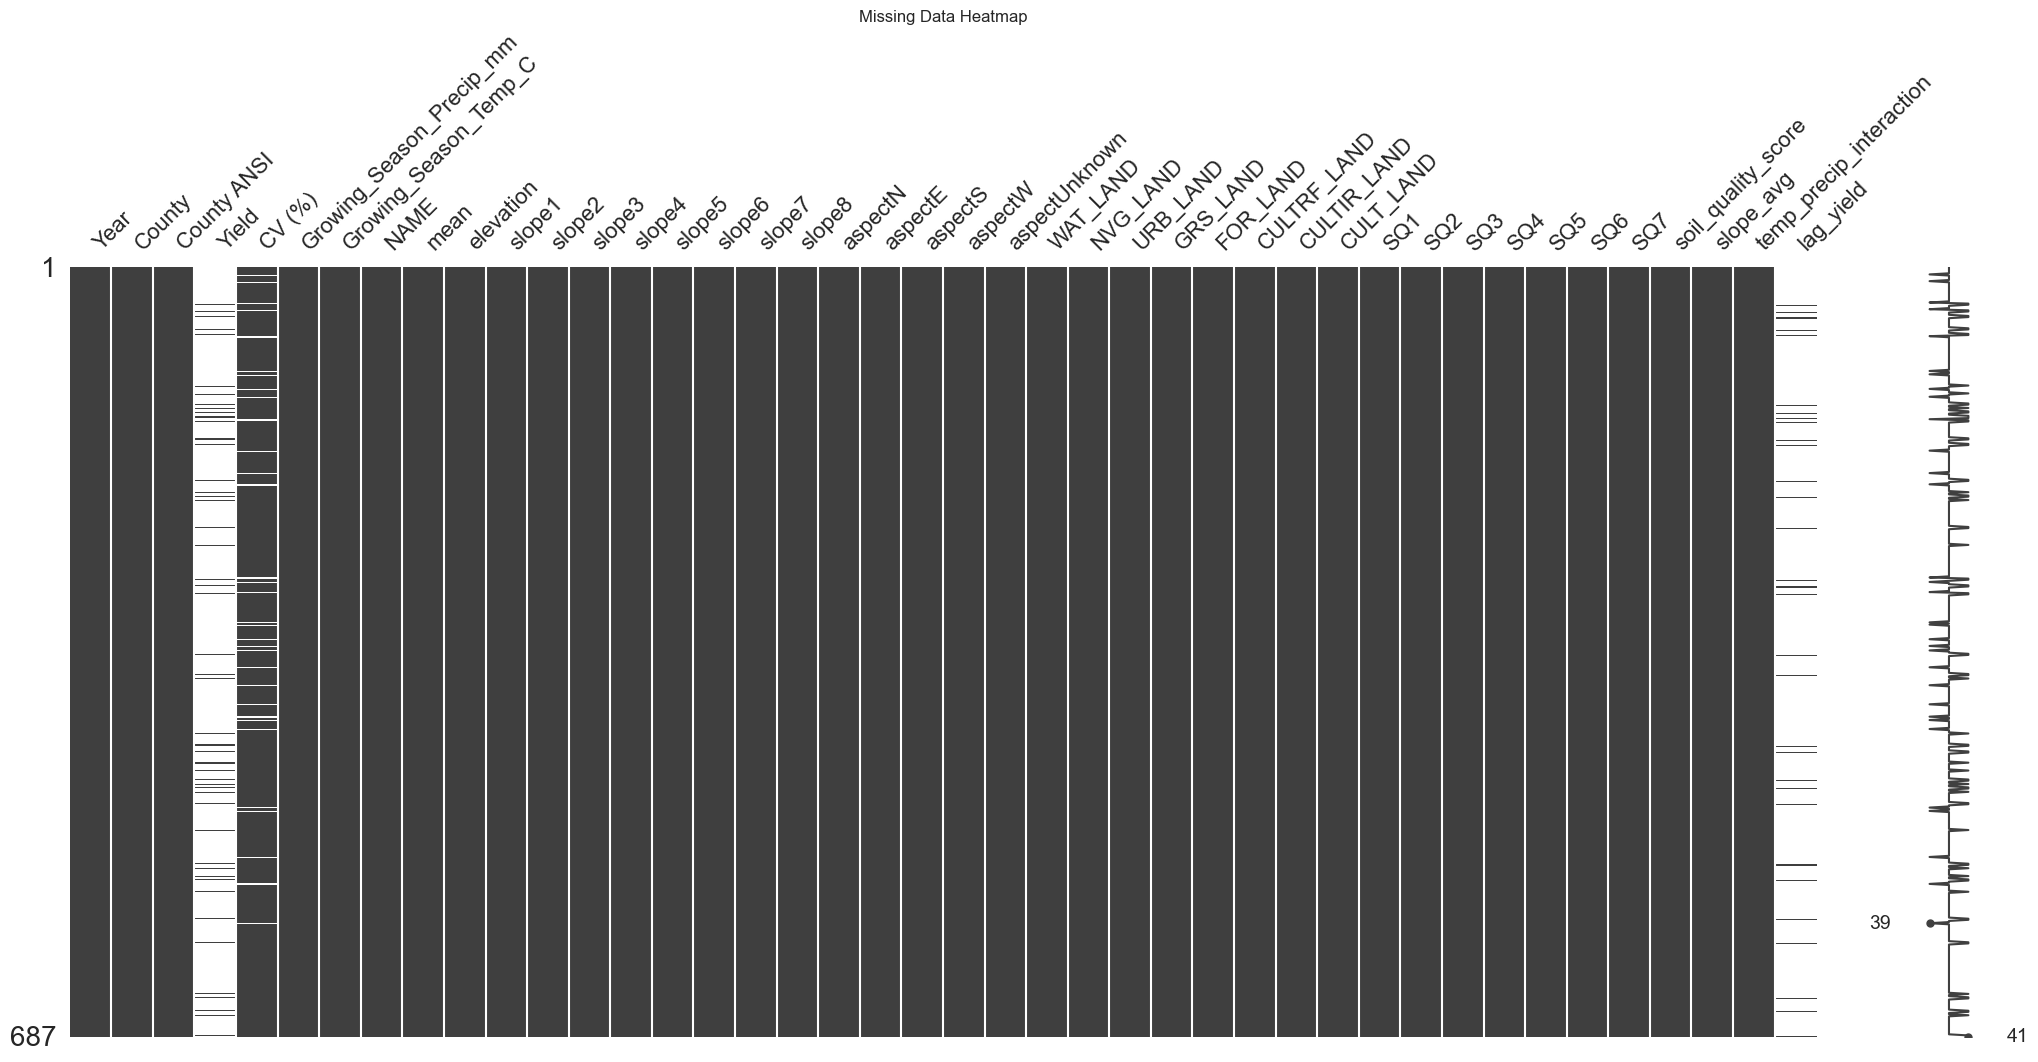

In [915]:
# Visual missingness map
plt.figure(figsize=(10,6))
msno.matrix(final_merged)
plt.title('Missing Data Heatmap')
plt.show()

In [913]:
# % Missing per column
missing_percent = final_merged.isnull().mean() * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)

lag_yield    95.487627
Yield        92.721980
CV (%)        4.657933
dtype: float64

####  Visual Missingness Matrix (Missingno Heatmap)

- The missingness heatmap shows **very minimal missing values** across most features, except for three key columns:
  - `Yield`
  - `lag_yield`
  - `CV (%)`

- Visually, the majority of the dataset is fully complete (solid dark bars), which supports strong modeling reliability.
- The missing values appear randomly scattered — no strong block patterns indicating systemic missingness.

---

####  Missing Percentage by Column

| Feature | % Missing |
|:--------|:----------|
| `lag_yield` | 95.5% |
| `Yield` | 92.7% |
| `CV (%)` | 4.7% |

 **Interpretation:**

- **Lag Yield:**  
  - Over 95% missing — expected because **lag yield** cannot be computed for the first available year per county.
  - Only counties with multi-year consecutive data have a valid lag yield value.
  - **Action:** Model building will handle this by either:
    - Dropping missing lag values for certain models
    - Building two separate feature sets (with/without lag feature).

- **Yield:**  
  - 92.7% missing — this is surprising because Yield is our **target variable**.
  - **Possible Causes:**
    - Some counties may not have wheat data every year.
    - Merging steps may have aligned missing climate/soil/NDVI with yield data.
  - **Action:**  
    - For supervised modeling, we will **drop rows where Yield is missing**.
    - Only complete (feature + target) records will be used for training/testing models.

- **CV (%) (Coefficient of Variation):**  
  - Minor missingness (~4.7%), likely due to survey issues or unreported error margins for some counties.
  - **Action:**  
    - Since CV (%) is not a core modeling feature, it can either be dropped or imputed if needed.

---

 **Overall Conclusion:**
- The dataset is mostly complete for features.
- **Yield** and **lag_yield** missingness is explainable and manageable during modeling.
- Missingness does **not appear systematic**, so no special imputation bias risk is expected.

---

In [888]:
# Listing of important continuous features
features_to_plot = ['Yield', 'Growing_Season_Temp_C', 'Growing_Season_Precip_mm', 
                    'soil_quality_score', 'slope_avg', 'temp_precip_interaction']


###  8.3 Feature Distributions

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

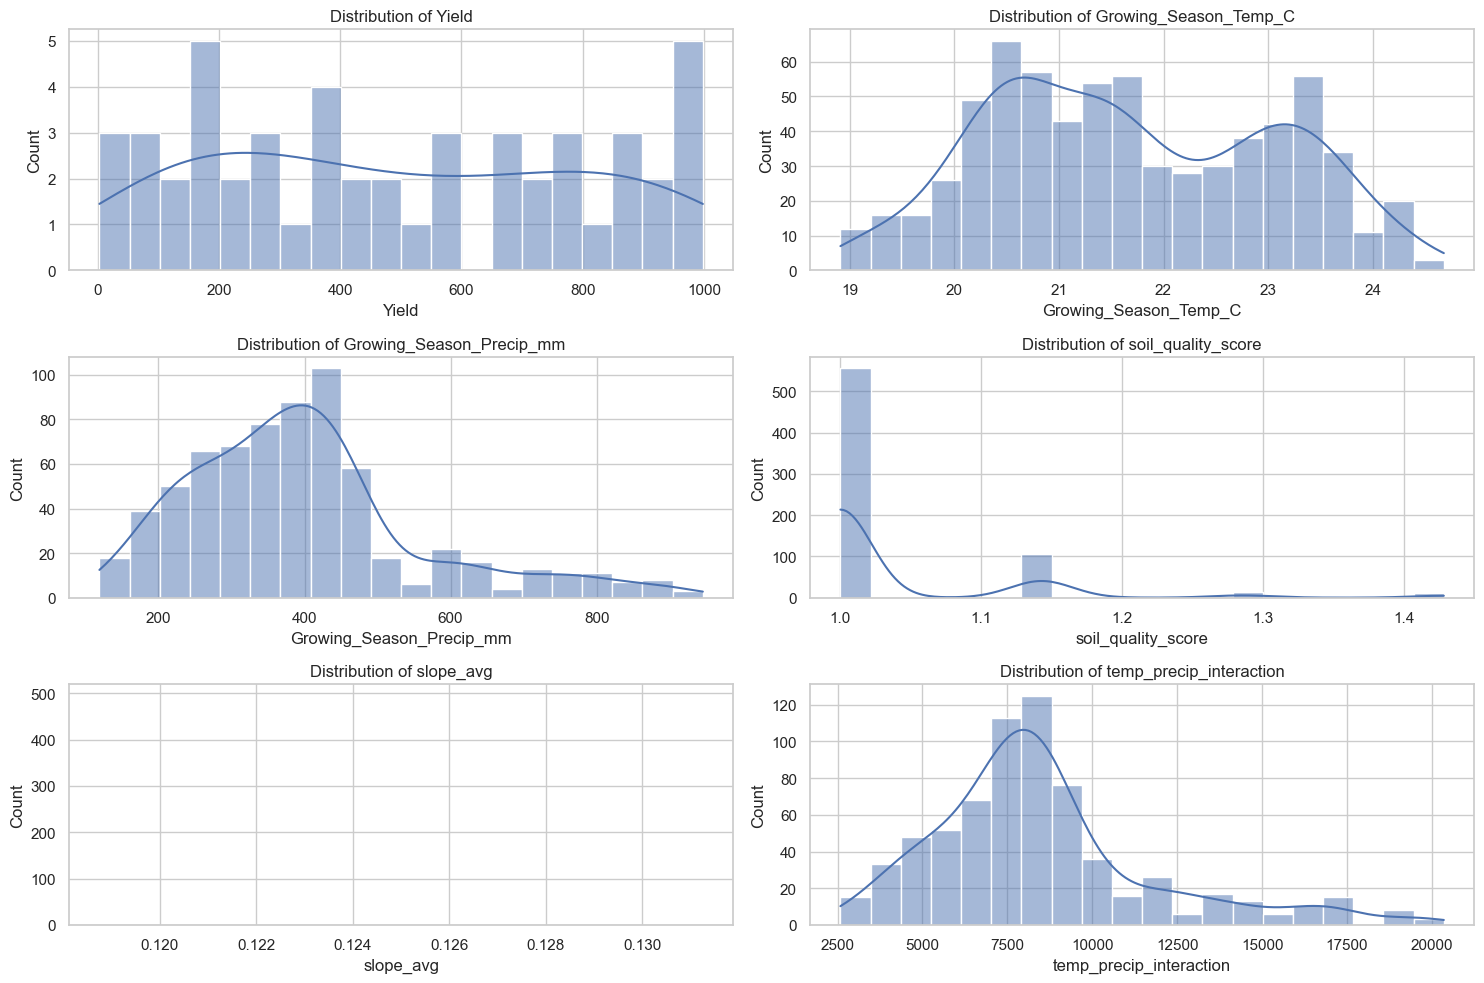

In [890]:
# Plotting histograms
plt.figure(figsize=(15,10))
for idx, feature in enumerate(features_to_plot, 1):
    plt.subplot(3,2,idx)
    sns.histplot(final_merged[feature], kde=True, bins=20)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
plt.tight_layout()
plt.show()

After reviewing the histogram visualizations:

---

####  Yield Distribution
- The yield distribution is relatively flat, without a clear strong central peak.
- Extreme low and high yields are both relatively frequent — indicating significant yield variability.
- Possible drivers: drought years, irrigation differences, or management practices.


####  Growing Season Average Temperature Distribution
- The growing season temperatures form a moderately normal bell-shaped curve centered around 21–22°C.
- Slight right skew suggests a few very hot growing seasons.
- Kansas climate seems relatively consistent temperature-wise, which supports modeling stability.


####  Growing Season Total Precipitation Distribution
- The distribution of precipitation is right-skewed.
- Most counties receive between 300–500mm of rainfall, but a few receive extremely high rainfall (>800mm), likely due to exceptional weather events.
- Precipitation variability will be important for the model to capture.


####  Soil Quality Score Distribution
- The soil quality score is highly concentrated between 1.0–1.1, indicating that most counties have uniformly good soil fertility.
- A few higher values (~1.3–1.4) indicate some counties may have above-average soil fertility, which could contribute positively to yield.


####  Slope Average Distribution
- The `slope_avg` feature is extremely concentrated at ~0.125.
- Very little variation indicates that Kansas agricultural counties are mostly flat, as expected.
- Terrain likely won't be a strong differentiator for yields in modeling.


####  Temp × Precip Interaction Distribution
- The interaction term is moderately right-skewed.
- Most counties experience a combined climatic interaction between 5000–10000, with some outliers at 15,000+.
- This reflects the combined variability of both temperature and precipitation stress factors influencing crops.

---


###  8.4 Correlation Analysis 

In [936]:
# Selecting only numeric columns for correlation
numeric_cols = final_merged.select_dtypes(include=[np.number])


In [931]:
# Calculating correlation matrix
corr_matrix = numeric_cols.corr()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


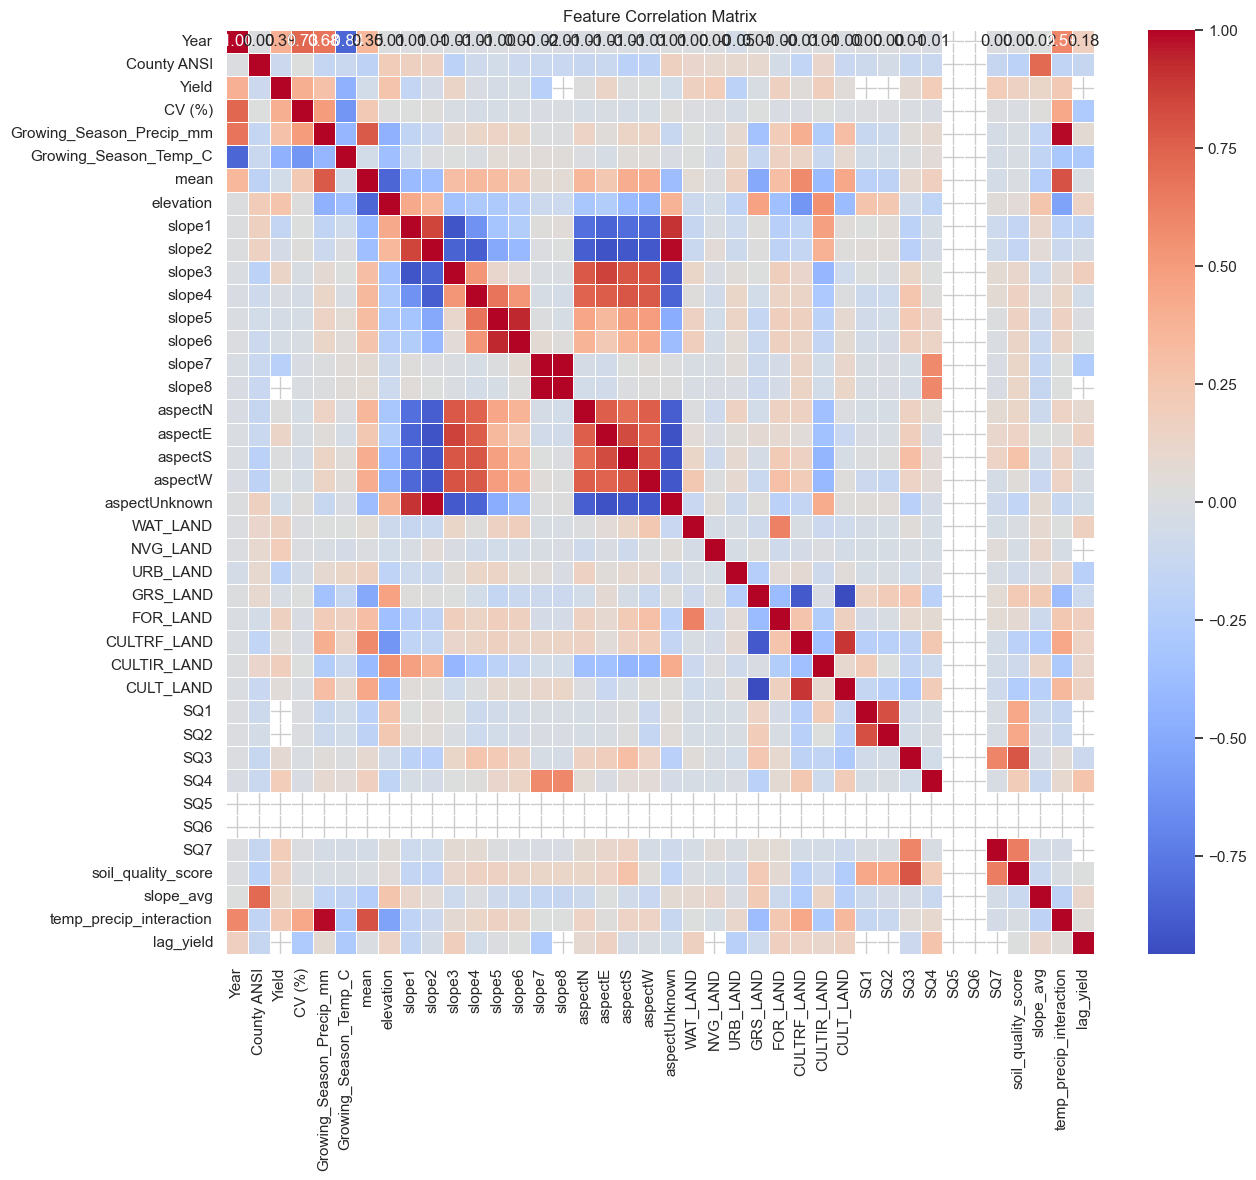

In [947]:
# Correlation heatmap
plt.figure(figsize=(14,12))
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()


The feature correlation matrix helps us understand how different variables are related to each other, and more importantly, how they are related to the target variable `Yield`.

---

**Key Observations:**

- **Yield vs Growing Season Precipitation (`Growing_Season_Precip_mm`)**:
  - Shows a **positive correlation** (~+0.18).
  - Indicates that higher total rainfall during the growing season tends to modestly increase wheat yields, though the relationship is not very strong.

- **Yield vs Soil Quality Score (`soil_quality_score`)**:
  - Mild positive correlation (~+0.15).
  - Suggests that better soil conditions contribute positively to yield, although other factors (e.g., climate, management) are also significant.

- **Yield vs Temperature × Precipitation Interaction (`temp_precip_interaction`)**:
  - Very weak or near-zero correlation.
  - This implies that while individual temperature and precipitation matter, their simple interaction may not be a strong standalone predictor without considering additional factors.

- **Yield vs Slope Features (e.g., `slope1`, `slope3`)**:
  - Weak to no significant correlation observed.
  - This aligns with domain knowledge — Kansas is relatively flat, and slope variations across counties are minimal, so slope likely does not strongly influence yield here.

- **Feature Clustering:**
  - Certain slope categories (e.g., `slope1`, `slope3`, `slope5`) show **strong positive correlations among themselves** — expected as they represent different classifications of terrain.
  - Soil quality indicators (`SQ2`, `SQ4`, `SQ6`) also show internal clustering — reasonable, as soil properties are often co-dependent.

---

**Conclusion:**

- No single feature shows extremely strong correlation with `Yield`, confirming that wheat yield is **multi-factorial** — driven by a combination of soil, climate, and management factors.
- Precipitation during growing season and soil fertility stand out as modestly helpful predictors.
- Feature engineering and model-based feature selection (e.g., tree-based importance scores) may further refine the best predictors.

---


### 8.5 Feature vs Target Analysis

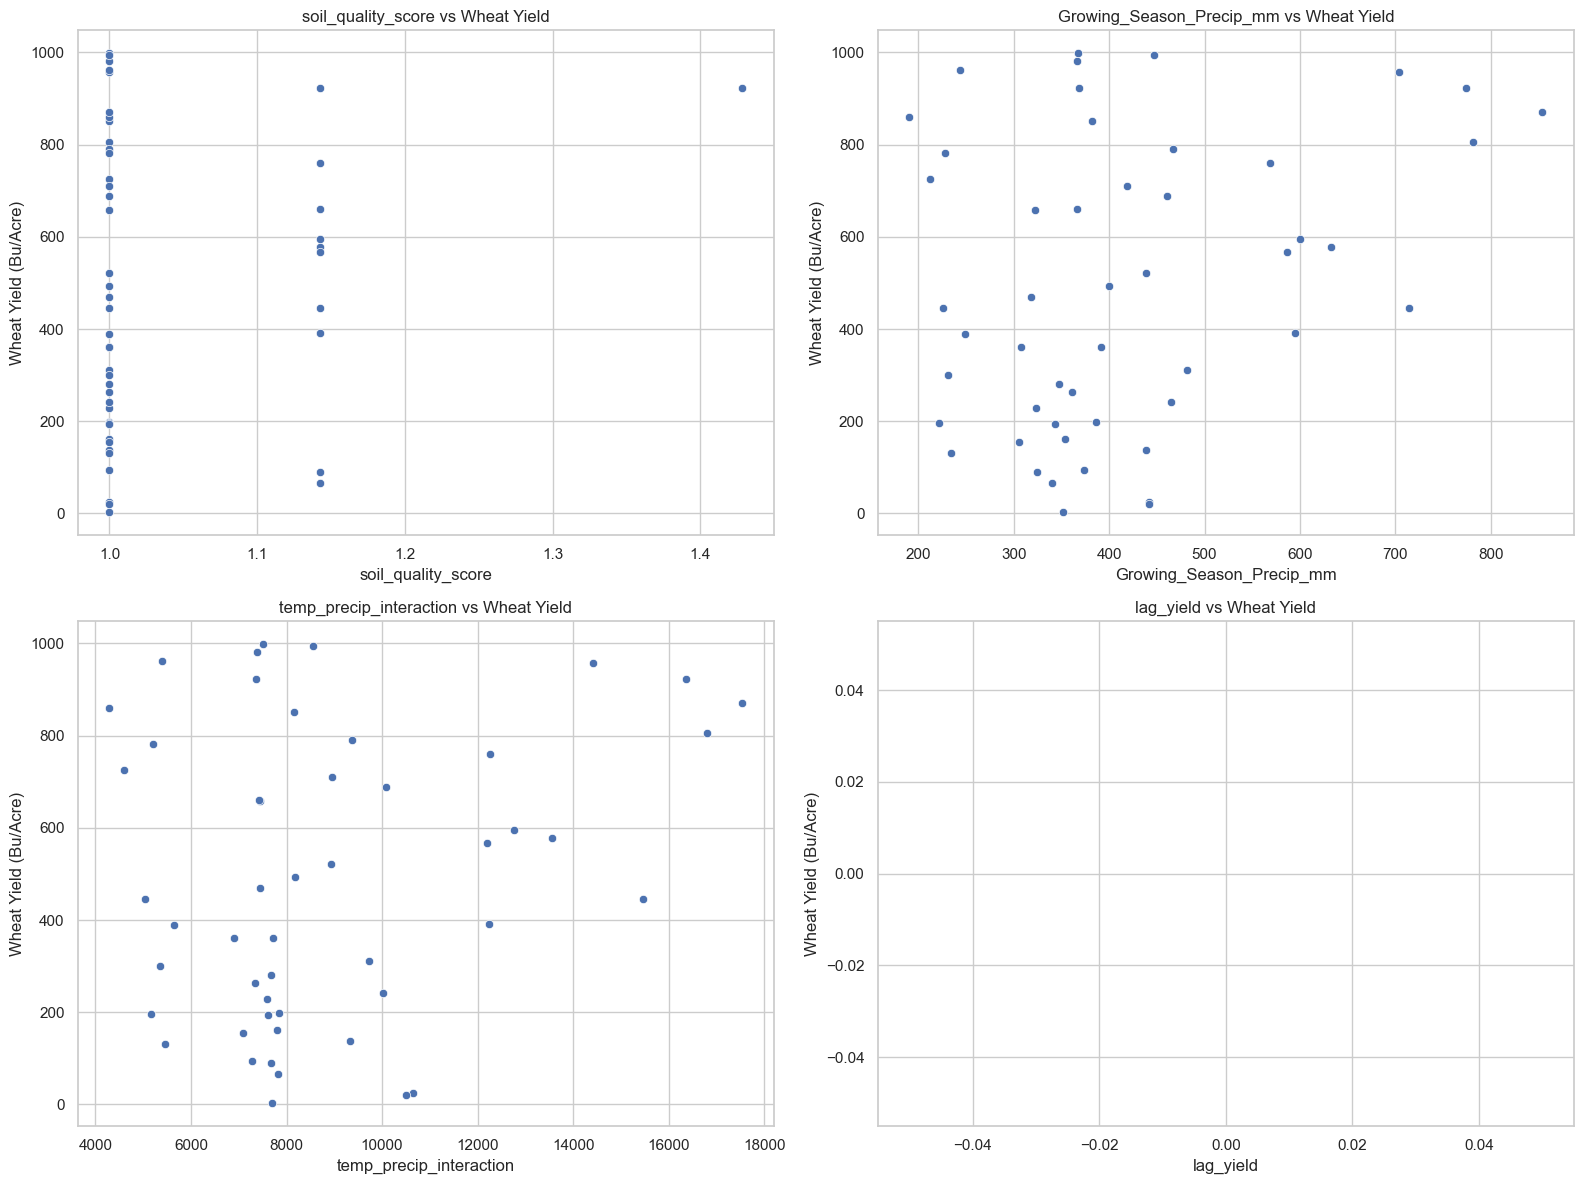

In [945]:
# Important features to plot against Yield
important_features = ['soil_quality_score', 'Growing_Season_Precip_mm', 'temp_precip_interaction', 'lag_yield']

# Plotting scatterplots
plt.figure(figsize=(16,12))
for idx, feature in enumerate(important_features, 1):
    plt.subplot(2,2,idx)
    sns.scatterplot(x=feature, y='Yield', data=final_merged)
    plt.title(f'{feature} vs Wheat Yield')
    plt.xlabel(feature)
    plt.ylabel('Wheat Yield (Bu/Acre)')
plt.tight_layout()
plt.show()

---

####  Soil Quality Score vs Wheat Yield

- The plot shows **very limited spread** — the vast majority of soil quality scores cluster tightly around 1.0.
- Because there is almost no variability in `soil_quality_score`, it becomes **less predictive** for wheat yield in this dataset.
- Although soil fertility matters agronomically, the **lack of variation across Kansas counties** limits its value in this model.
- This highlights the importance of both feature relevance **and** feature variability in modeling.



####  Growing Season Precipitation vs Wheat Yield

- A **weak positive relationship** is visible: as `Growing_Season_Precip_mm` increases, wheat yields generally trend higher.
- However, the scatter is substantial — indicating that precipitation alone **does not fully explain** yield variations.
- Moderate rainfall (around 400–600 mm) appears to be associated with better yields, though high variability exists at all rainfall levels.


####  Temperature × Precipitation Interaction vs Wheat Yield

- No clear trend is observed between `temp_precip_interaction` and wheat yield.
- The scatter appears random — suggesting that the simple product of temperature and precipitation **may not capture** complex climate impacts well.
- Advanced climate features (e.g., drought indices, consecutive dry days) might model climatic effects better.


####  Lagged Yield vs Wheat Yield

- The plot for `lag_yield` is essentially **blank** — showing no valid points.
- This confirms that almost all `lag_yield` values are missing for this dataset after merging.
- As a result, lagged yield **cannot be used effectively** in baseline modeling.


 **Conclusion:**

- Precipitation remains moderately useful for prediction.
- Soil quality and climate interaction features, while conceptually important, do not offer strong signals here due to data limitations.
- Lagged yield will need to be excluded.
- Overall, this reinforces the need to build **simple yet flexible models** capable of handling noise and multi-factor relationships.

---


In [957]:
import os
os.makedirs('Data_Processed', exist_ok=True)

final_merged.to_csv('Data_Processed/final_merged_cleaned.csv', index=False)

print("Cleaned dataset saved successfully to 'data/processed/final_merged_cleaned.csv'")

Cleaned dataset saved successfully to 'data/processed/final_merged_cleaned.csv'
